# 🛒 Amazon India — Product Price Prediction Engine
### Real-World Data · Multiple Linear Regression · Polynomial Regression

---

## 📌 Business Problem Statement

    Amazon India hosts millions of products across hundreds of categories.
    Every seller faces the same core question:
    
    "Given my product's actual cost, discount, rating, and reviews —
     what should the discounted listing price be to maximize sales?"
    
    This project builds a Machine Learning model trained on real Amazon India
    scraped data to predict the optimal discounted price for any product.

---

## 🎯 Business Objective

    Input  : actual_price, discount_percentage, rating, rating_count, category
    Output : discounted_price — the predicted optimal listing price (₹)

    Value for sellers :
    → Know the right price before listing — not after losing sales
    → Understand how rating and review count affect pricing power
    → See which categories command the highest prices
    → Make data-driven discount decisions instead of guessing

---

## 📊 Dataset

    Source  : Amazon India — real scraped product data (2023)
    Rows    : 1465 products
    Columns : 16 raw columns → 6 usable after dropping text/link/ID columns

---

## 🗺️ Pipeline

| Step | Task |
|------|------|
| 0 | Import Libraries |
| 1 | Load Dataset + Basic Info |
| 2 | EDA — Column by Column |
| 3 | Data Cleaning — Every Column Fixed |
| 4 | ✅ Null Check Gate — Zero Before Proceeding |
| 5 | Feature Engineering |
| 6 | Encoding |
| 7 | Correlation Analysis |
| 8 | X and Y Split — Explicit by Column Name |
| 9 | Train / Test Split + Standardization |
| 10 | Model 1 — Multiple Linear Regression |
| 11 | Model 2 — Polynomial Regression (Degree 2) |
| 12 | Cross Validation |
| 13 | Performance Metrics |
| 14 | Residual Analysis |
| 15 | Feature Importance |
| 16 | Business Simulation — Live Price Prediction |

---

## 📋 Column Dictionary

| Column | Keep/Drop | Reason | Mess |
|--------|-----------|--------|------|
| `product_id` | Drop | Identifier | — |
| `product_name` | Drop | Free text | — |
| `category` | Keep → clean | Main category hidden in pipe-chain | `Computers&Accessories\|Cables\|USB` format |
| `discounted_price` | Keep → **TARGET** | This is what we predict | `₹` prefix + `,` separators |
| `actual_price` | Keep | Strong price signal | `₹` prefix + `,` separators |
| `discount_percentage` | Keep | Direct pricing lever | `%` suffix |
| `rating` | Keep | Quality signal | One rogue `\|` value |
| `rating_count` | Keep | Popularity signal | `,` separators + 2 NaN + Indian format `1,79,691` |
| `about_product` | Drop | Long text | — |
| `user_id` | Drop | Identifier | — |
| `user_name` | Drop | Identifier | — |
| `review_id` | Drop | Identifier | — |
| `review_title` | Drop | Free text | — |
| `review_content` | Drop | Free text | — |
| `img_link` | Drop | URL | — |
| `product_link` | Drop | URL | — |

---

## 📦 Step 0 — Import Libraries

In [134]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

---
## 📂 Step 1 — Load Dataset + Basic Info

In [135]:
df = pd.read_csv("amazon.csv")
df.head()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


In [136]:
df.tail()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
1460,B08L7J3T31,Noir Aqua - 5pcs PP Spun Filter + 1 Spanner | ...,Home&Kitchen|Kitchen&HomeAppliances|WaterPurif...,₹379,₹919,59%,4,"1,090",SUPREME QUALITY 90 GRAM 3 LAYER THIK PP SPUN F...,"AHITFY6AHALOFOHOZEOC6XBP4FEA,AFRABBODZJZQB6Z4U...","Prabha ds,Raghuram bk,Real Deal,Amazon Custome...","R3G3XFHPBFF0E8,R3C0BZCD32EIGW,R2EBVBCN9QPD9R,R...","Received the product without spanner,Excellent...","I received product without spanner,Excellent p...",https://m.media-amazon.com/images/I/41fDdRtjfx...,https://www.amazon.in/Noir-Aqua-Spanner-Purifi...
1461,B01M6453MB,Prestige Delight PRWO Electric Rice Cooker (1 ...,Home&Kitchen|Kitchen&HomeAppliances|SmallKitch...,"₹2,280","₹3,045",25%,4.1,"4,118","230 Volts, 400 watts, 1 Year","AFG5FM3NEMOL6BNFRV2NK5FNJCHQ,AGEINTRN6Z563RMLH...","Manu Bhai,Naveenpittu,Evatira Sangma,JAGANNADH...","R3DDL2UPKQ2CK9,R2SYYU1OATVIU5,R1VM993161IYRW,R...","ok,everything was good couldn't return bcoz I ...","ok,got everything as mentioned but the measuri...",https://m.media-amazon.com/images/I/41gzDxk4+k...,https://www.amazon.in/Prestige-Delight-PRWO-1-...
1462,B009P2LIL4,Bajaj Majesty RX10 2000 Watts Heat Convector R...,"Home&Kitchen|Heating,Cooling&AirQuality|RoomHe...","₹2,219","₹3,080",28%,3.6,468,International design and styling|Two heat sett...,"AGVPWCMAHYQWJOQKMUJN4DW3KM5Q,AF4Q3E66MY4SR7YQZ...","Nehal Desai,Danish Parwez,Amazon Customer,Amaz...","R1TLRJVW4STY5I,R2O455KRN493R1,R3Q5MVGBRIAS2G,R...","very good,Work but front melt after 2 month,Go...","plastic but cool body ,u have to find sturdy s...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Bajaj-RX-10-2000-Watt-Co...
1463,B00J5DYCCA,Havells Ventil Air DSP 230mm Exhaust Fan (Pist...,"Home&Kitchen|Heating,Cooling&AirQuality|Fans|E...","₹1,399","₹1,890",26%,4,"8,031",Fan sweep area: 230 MM ; Noise level: (40 - 45...,"AF2JQCLSCY3QJATWUNNHUSVUPNQQ,AFDMLUXC5LS5RXDJS...","Shubham Dubey,E.GURUBARAN,Mayank S.,eusuf khan...","R39Q2Y79MM9SWK,R3079BG1NIH6MB,R29A31ZELTZNJM,R...","Fan Speed is slow,Good quality,Good product,go...",I have installed this in my kitchen working fi...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Havells-Ventilair-230mm-...
1464,B01486F4G6,Borosil Jumbo 1000-Watt Grill Sandwich Maker (...,Home&Kitchen|Kitchen&HomeAppliances|SmallKitch...,"₹2,863","₹3,690",22%,4.3,"6,987","Brand-Borosil, Specification â€“ 23V ~ 5Hz;1 W...","AFGW5PT3R6ZAVQR4Y5MWVAKBZAYA,AG7QNJ2SCS5VS5VYY...","Rajib,Ajay B,Vikas Kahol,PARDEEP,Anindya Prama...","R20RBRZ0WEUJT9,ROKIFK9R2ISSE,R30EEG2FNJSN5I,R2...","Works perfect,Ok good product,Nice Product. Re...",It does it job perfectly..only issue is temp c...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Borosil-Jumbo-1000-Watt-...


In [137]:
df.shape

(1465, 16)

In [138]:
df.columns.tolist()

['product_id',
 'product_name',
 'category',
 'discounted_price',
 'actual_price',
 'discount_percentage',
 'rating',
 'rating_count',
 'about_product',
 'user_id',
 'user_name',
 'review_id',
 'review_title',
 'review_content',
 'img_link',
 'product_link']

In [139]:
# ALL columns are object dtype — this is real scraped data
# Every numeric column has currency symbols, commas, % signs baked in
# This is exactly why cleaning is the most important step
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   product_id           1465 non-null   str  
 1   product_name         1465 non-null   str  
 2   category             1465 non-null   str  
 3   discounted_price     1465 non-null   str  
 4   actual_price         1465 non-null   str  
 5   discount_percentage  1465 non-null   str  
 6   rating               1465 non-null   str  
 7   rating_count         1463 non-null   str  
 8   about_product        1465 non-null   str  
 9   user_id              1465 non-null   str  
 10  user_name            1465 non-null   str  
 11  review_id            1465 non-null   str  
 12  review_title         1465 non-null   str  
 13  review_content       1465 non-null   str  
 14  img_link             1465 non-null   str  
 15  product_link         1465 non-null   str  
dtypes: str(16)
memory usage: 4.7 MB


In [140]:
# describe() will show nothing useful here because all cols are object
# we will describe each column after cleaning it
df.describe()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
count,1465,1465,1465,1465,1465,1465,1465,1463,1465,1465,1465,1465,1465,1465,1465,1465
unique,1351,1337,211,550,449,92,28,1143,1293,1194,1194,1194,1194,1212,1412,1465
top,B07JW9H4J1,"Fire-Boltt Ninja Call Pro Plus 1.83"" Smart Wat...",Computers&Accessories|Accessories&Peripherals|...,₹199,₹999,50%,4.1,"9,378",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AHIKJUDTVJ4T6DV6IUGFYZ5LXMPA,AE55KTFVNXYFD5FPY...","$@|\|TO$|-|,Sethu madhav,Akash Thakur,Burger P...","R3F4T5TRYPTMIG,R3DQIEC603E7AY,R1O4Z15FD40PV5,R...","Worked on iPhone 7 and didn’t work on XR,Good ...","I am not big on camera usage, personally. I wa...",https://m.media-amazon.com/images/I/413sCRKobN...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
freq,3,5,233,53,120,56,244,9,6,10,10,10,10,8,3,1


In [141]:
# Missing values — rating_count has 2 NaN
df.isnull().sum()

product_id             0
product_name           0
category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 0
rating_count           2
about_product          0
user_id                0
user_name              0
review_id              0
review_title           0
review_content         0
img_link               0
product_link           0
dtype: int64

In [142]:
# No duplicate rows in this dataset
df.duplicated().sum()

np.int64(0)

---
## 🔍 Step 2 — EDA (Exploratory Data Analysis)

Inspect every column we will use — before touching anything

In [143]:
# discounted_price — TARGET
# has ₹ prefix and , separators
df["discounted_price"].value_counts().head(10)

discounted_price
₹199      53
₹299      46
₹399      36
₹499      34
₹349      31
₹599      28
₹1,499    26
₹999      25
₹1,199    23
₹1,799    21
Name: count, dtype: int64

In [144]:
# actual_price — has ₹ prefix and , separators
df["actual_price"].value_counts().head(10)

actual_price
₹999      120
₹499       71
₹1,999     56
₹1,499     37
₹399       34
₹599       33
₹699       29
₹799       24
₹2,999     22
₹1,299     21
Name: count, dtype: int64

In [145]:
# discount_percentage — has % suffix
df["discount_percentage"].value_counts().head(10)

discount_percentage
50%    56
60%    56
0%     49
80%    37
55%    36
38%    34
43%    32
62%    32
65%    31
28%    30
Name: count, dtype: int64

In [146]:
# rating — has ONE bad value '|' mixed with float strings
df["rating"].value_counts()
# look for the | value in the output

rating
4.1    244
4.3    230
4.2    228
4.0    129
3.9    123
4.4    123
3.8     86
4.5     75
4       52
3.7     42
3.6     35
3.5     26
4.6     17
3.3     16
3.4     10
4.7      6
3.1      4
5.0      3
3.0      3
4.8      3
3.2      2
2.8      2
2.3      1
|        1
2        1
3        1
2.6      1
2.9      1
Name: count, dtype: int64

In [147]:
# rating_count — has , separators AND Indian number format
# Indian format example: 1,79,691 = 179691 (not standard western 1,791,691)
df["rating_count"].value_counts().head(10)

rating_count
9,378     9
18,998    8
24,269    7
43,994    6
32,840    5
20,850    5
1,075     5
13,552    5
1,423     5
13,937    5
Name: count, dtype: int64

In [148]:
# category — pipe-separated full hierarchy
# format: MainCategory|SubCategory|SubSubCategory|...
# we only need the first part (MainCategory)
df["category"].head(10).tolist()

['Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBCables',
 'Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBCables',
 'Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBCables',
 'Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBCables',
 'Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBCables',
 'Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBCables',
 'Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBCables',
 'Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBCables',
 'Computers&Accessories|NetworkingDevices|NetworkAdapters|WirelessUSBAdapters',
 'Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBCables']

In [149]:
# Main category distribution — split on | and take first element
df["category"].str.split("|").str[0].value_counts()

category
Electronics              526
Computers&Accessories    453
Home&Kitchen             448
OfficeProducts            31
MusicalInstruments         2
HomeImprovement            2
Toys&Games                 1
Car&Motorbike              1
Health&PersonalCare        1
Name: count, dtype: int64

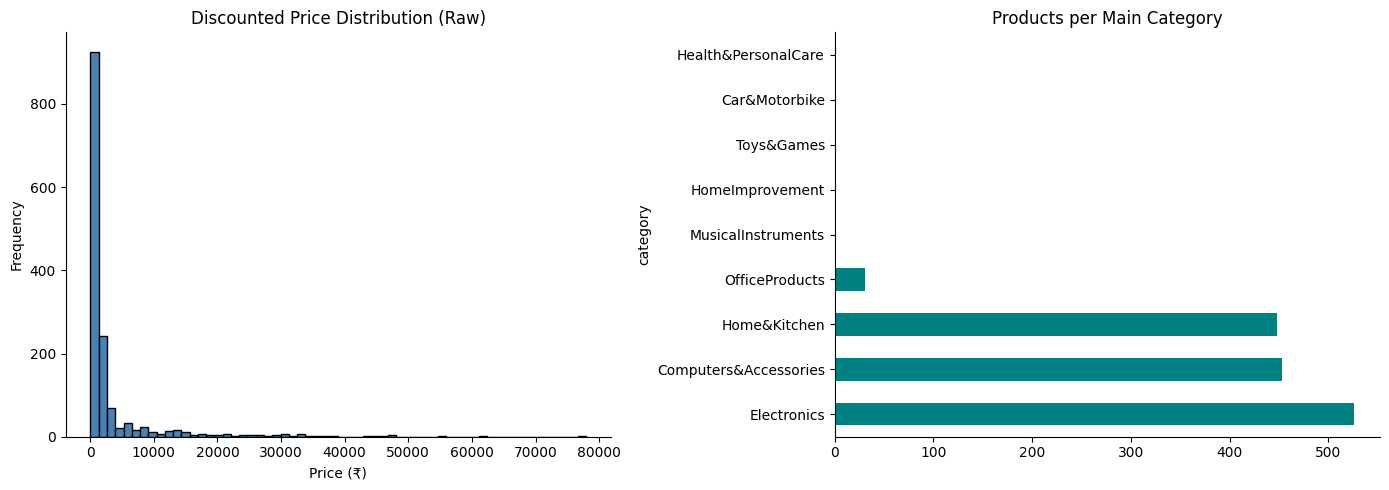

In [150]:
# --- EDA Visualizations ---

# Target distribution (need to strip ₹ and , first for plotting)
discounted_temp = df["discounted_price"].str.replace("₹","",regex=False).str.replace(",","",regex=False)
discounted_temp = pd.to_numeric(discounted_temp, errors="coerce")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

discounted_temp.dropna().plot(kind="hist", bins=60, ax=axes[0], color="steelblue", edgecolor="black")
axes[0].set_title("Discounted Price Distribution (Raw)")
axes[0].set_xlabel("Price (₹)")

df["category"].str.split("|").str[0].value_counts().plot(kind="barh", ax=axes[1], color="teal")
axes[1].set_title("Products per Main Category")

plt.tight_layout()
plt.show()

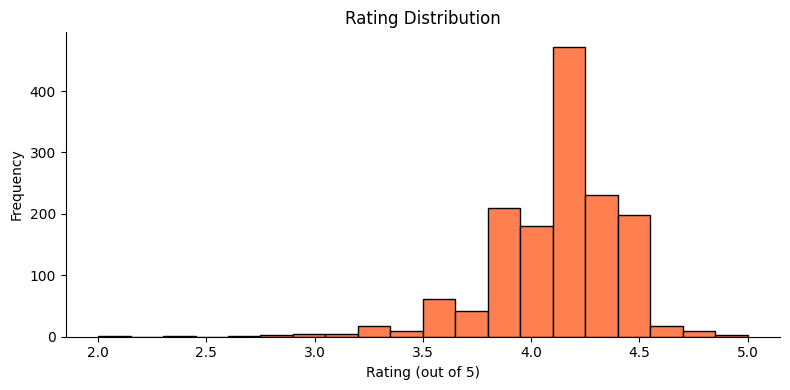

In [151]:
# Rating distribution — after removing bad value
rating_temp = pd.to_numeric(df["rating"], errors="coerce")
rating_temp.dropna().plot(kind="hist", bins=20, color="coral", edgecolor="black", figsize=(8,4))
plt.title("Rating Distribution")
plt.xlabel("Rating (out of 5)")
plt.tight_layout()
plt.show()

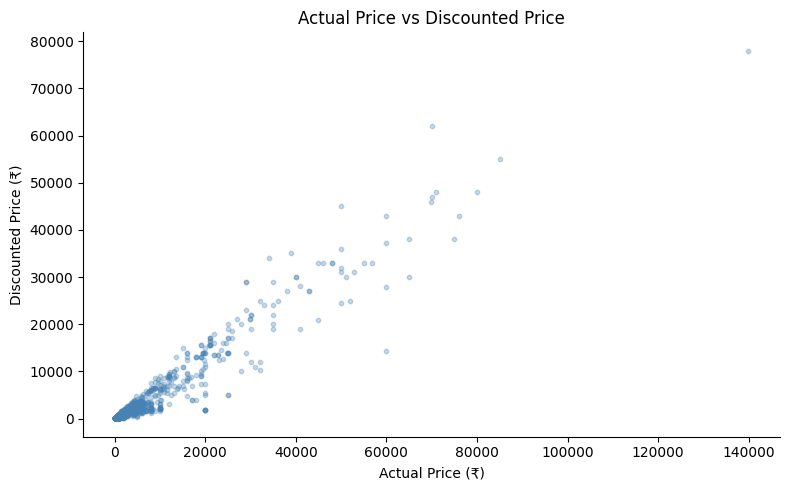

In [152]:
# Actual price vs discounted price — quick scatter
actual_temp = df["actual_price"].str.replace("₹","",regex=False).str.replace(",","",regex=False)
actual_temp = pd.to_numeric(actual_temp, errors="coerce")

plt.figure(figsize=(8,5))
plt.scatter(actual_temp, discounted_temp, alpha=0.3, color="steelblue", s=10)
plt.xlabel("Actual Price (₹)")
plt.ylabel("Discounted Price (₹)")
plt.title("Actual Price vs Discounted Price")
plt.tight_layout()
plt.show()

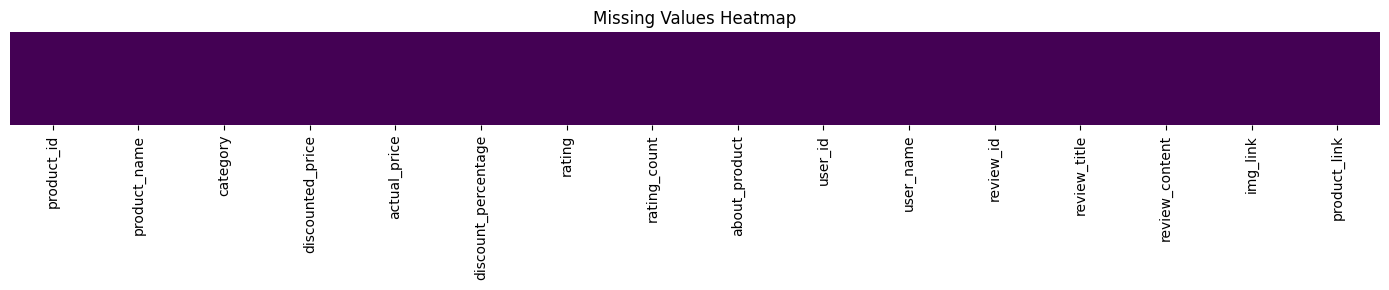

In [153]:
# Missing values heatmap
plt.figure(figsize=(14, 3))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.tight_layout()
plt.show()

---
## 🧹 Step 3 — Data Cleaning

    Lessons applied from previous projects :
    
    Rule 1 → Always work on a copy — never modify original df
    Rule 2 → pd.to_numeric() BEFORE fillna() — object dtype silently ignores fillna
    Rule 3 → Use direct assignment col = col.fillna() — not inplace=True
              inplace=True is unreliable in newer pandas versions
    Rule 4 → Fix outliers BEFORE filling NaN — outlier removal creates fresh NaN
    Rule 5 → Drop useless columns FIRST — keeps df_clean lean throughout
    Rule 6 → Null check gate before Feature Engineering — non-negotiable

In [154]:
# Work on a copy — never touch the original
df_clean = df.copy()

### 3.1 — Drop Useless Columns First

    Drop identifiers, free text, URLs — they carry zero ML signal
    Do this first so every step after works on a lean dataframe

In [155]:
cols_to_drop = [
    "product_id",      # identifier
    "product_name",    # free text
    "about_product",   # long free text
    "user_id",         # identifier
    "user_name",       # identifier
    "review_id",       # identifier
    "review_title",    # free text
    "review_content",  # free text
    "img_link",        # URL
    "product_link"     # URL
]

df_clean.drop(cols_to_drop, axis=1, inplace=True)

# Confirm what remains
print("Remaining columns:", df_clean.columns.tolist())
print("Shape:", df_clean.shape)

Remaining columns: ['category', 'discounted_price', 'actual_price', 'discount_percentage', 'rating', 'rating_count']
Shape: (1465, 6)


### 3.2 — Fix `category` (Extract main category from pipe-chain)

    Raw format: 'Computers&Accessories|Cables&Accessories|USBCables'
    We only need: 'Computers&Accessories'
    Split on | and take first element

In [156]:
# See raw format
df_clean["category"].head(5).tolist()

['Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBCables',
 'Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBCables',
 'Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBCables',
 'Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBCables',
 'Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBCables']

In [157]:
# Extract main category only — split on | take index 0
df_clean["category"] = df_clean["category"].str.split("|").str[0]

# Verify
df_clean["category"].value_counts()

category
Electronics              526
Computers&Accessories    453
Home&Kitchen             448
OfficeProducts            31
MusicalInstruments         2
HomeImprovement            2
Toys&Games                 1
Car&Motorbike              1
Health&PersonalCare        1
Name: count, dtype: int64

### 3.3 — Fix `discounted_price` — TARGET (Remove ₹ and ,)

    Format: '₹1,099' → 1099.0
    Same technique as Playstore $ removal and flight dataset currency cleaning

In [158]:
# Check the format
df_clean["discounted_price"].head(5).tolist()

['₹399', '₹199', '₹199', '₹329', '₹154']

In [159]:
# Step 1 : remove ₹ symbol
df_clean["discounted_price"] = df_clean["discounted_price"].str.replace("₹", "", regex=False)

# Step 2 : remove , separators
df_clean["discounted_price"] = df_clean["discounted_price"].str.replace(",", "", regex=False)

# Step 3 : convert to numeric
df_clean["discounted_price"] = pd.to_numeric(df_clean["discounted_price"], errors="coerce")

df_clean["discounted_price"].describe()

count     1465.000000
mean      3125.310874
std       6944.304394
min         39.000000
25%        325.000000
50%        799.000000
75%       1999.000000
max      77990.000000
Name: discounted_price, dtype: float64

### 3.4 — Fix `actual_price` (Remove ₹ and ,)

    Same technique as discounted_price

In [160]:
df_clean["actual_price"] = df_clean["actual_price"].str.replace("₹", "", regex=False)
df_clean["actual_price"] = df_clean["actual_price"].str.replace(",", "", regex=False)
df_clean["actual_price"] = pd.to_numeric(df_clean["actual_price"], errors="coerce")

df_clean["actual_price"].describe()

count      1465.000000
mean       5444.990635
std       10874.826864
min          39.000000
25%         800.000000
50%        1650.000000
75%        4295.000000
max      139900.000000
Name: actual_price, dtype: float64

### 3.5 — Fix `discount_percentage` (Remove % suffix)

In [161]:
# Format: '64%' → 64.0
df_clean["discount_percentage"] = df_clean["discount_percentage"].str.replace("%", "", regex=False)
df_clean["discount_percentage"] = pd.to_numeric(df_clean["discount_percentage"], errors="coerce")

df_clean["discount_percentage"].describe()

count    1465.000000
mean       47.691468
std        21.635905
min         0.000000
25%        32.000000
50%        50.000000
75%        63.000000
max        94.000000
Name: discount_percentage, dtype: float64

### 3.6 — Fix `rating` (Remove rogue '|' value → convert to numeric)

    rating has 28 unique values but one of them is '|' — not a number
    pd.to_numeric with errors='coerce' turns it into NaN automatically

In [162]:
# See the bad value
df_clean["rating"].unique()

<ArrowStringArray>
['4.2', '4.0', '3.9', '4.1', '4.3', '4.4', '4.5', '3.7', '3.3', '3.6', '3.4',
 '3.8', '3.5', '4.6', '3.2', '5.0', '4.7', '3.0', '2.8',   '4', '3.1', '4.8',
 '2.3',   '|',   '2',   '3', '2.6', '2.9']
Length: 28, dtype: str

In [163]:
# pd.to_numeric converts '|' to NaN automatically via errors='coerce'
df_clean["rating"] = pd.to_numeric(df_clean["rating"], errors="coerce")

# Check how many NaN were created
print("NaN in rating after conversion:", df_clean["rating"].isnull().sum())

df_clean["rating"].describe()

NaN in rating after conversion: 1


count    1464.000000
mean        4.096585
std         0.291674
min         2.000000
25%         4.000000
50%         4.100000
75%         4.300000
max         5.000000
Name: rating, dtype: float64

In [164]:
# Fill the NaN with median rating
df_clean["rating"] = df_clean["rating"].fillna(df_clean["rating"].median())
df_clean["rating"] = df_clean["rating"].round(1)

df_clean["rating"].describe()

count    1465.000000
mean        4.096587
std         0.291574
min         2.000000
25%         4.000000
50%         4.100000
75%         4.300000
max         5.000000
Name: rating, dtype: float64

### 3.7 — Fix `rating_count` (Remove , and handle Indian number format)

    Standard western: 1,791,691
    Indian format:    1,79,691  ← grouping is different
    Both cases: just remove ALL commas → convert to int
    Also has 2 NaN rows

In [165]:
# See Indian format example
df_clean["rating_count"].head(10).tolist()

['24,269',
 '43,994',
 '7,928',
 '94,363',
 '16,905',
 '24,871',
 '15,188',
 '30,411',
 '1,79,691',
 '43,994']

In [166]:
# Remove all commas regardless of grouping style
df_clean["rating_count"] = df_clean["rating_count"].str.replace(",", "", regex=False)
df_clean["rating_count"] = pd.to_numeric(df_clean["rating_count"], errors="coerce")

# Check NaN count — should show 2
print("NaN in rating_count:", df_clean["rating_count"].isnull().sum())

NaN in rating_count: 2


In [167]:
# Fill 2 NaN with median
df_clean["rating_count"] = df_clean["rating_count"].fillna(df_clean["rating_count"].median())
df_clean["rating_count"] = df_clean["rating_count"].astype("int32")

df_clean["rating_count"].describe()

count      1465.000000
mean      18277.634812
std       42727.398216
min           2.000000
25%        1191.000000
50%        5179.000000
75%       17325.000000
max      426973.000000
Name: rating_count, dtype: float64

---
## 🚦 Step 4 — Null Check Gate ✅

    Mandatory checkpoint — must show zero everywhere before Feature Engineering
    
    Lesson from previous project :
    NaN in a source column silently poisons every feature built from it
    Feature engineering on top of NaN = garbage features

In [168]:
df_clean.isnull().sum()

category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 0
rating_count           0
dtype: int64

In [169]:
total_nulls = df_clean.isnull().sum().sum()
print("Total null values remaining:", total_nulls)

if total_nulls == 0:
    print("✅ All clean — safe to proceed to Feature Engineering")
else:
    print("❌ Stop — fix nulls above before continuing")

Total null values remaining: 0
✅ All clean — safe to proceed to Feature Engineering


In [170]:
# Also check dtypes — everything numeric must be float or int, not object
df_clean.dtypes

category                object
discounted_price       float64
actual_price           float64
discount_percentage      int64
rating                 float64
rating_count             int32
dtype: object

In [171]:
# Final look at clean data
df_clean.head()

,category,discounted_price,actual_price,discount_percentage,rating,rating_count
0,Computers&Accessories,399.0,1099.0,64,4.2,24269
1,Computers&Accessories,199.0,349.0,43,4.0,43994
2,Computers&Accessories,199.0,1899.0,90,3.9,7928
3,Computers&Accessories,329.0,699.0,53,4.2,94363
4,Computers&Accessories,154.0,399.0,61,4.2,16905


---
## ⚙️ Step 5 — Feature Engineering

    We create new features that capture business signals not in the raw columns
    
    Important rule :
    Features must NOT mathematically reconstruct the target (discounted_price)
    That causes data leakage → fake 100% accuracy
    
    Safe features here use log transforms and ratios that add NEW signal

In [172]:
# 5.1 — savings_amount
# How much money is the customer saving?
# savings = actual_price - discounted_price
# Products with high savings tend to have more aggressive pricing

df_clean["savings_amount"] = (df_clean["actual_price"] - df_clean["discounted_price"]).round(2)

df_clean[["actual_price", "discounted_price", "savings_amount"]].head()

,actual_price,discounted_price,savings_amount
0,1099.0,399.0,700.0
1,349.0,199.0,150.0
2,1899.0,199.0,1700.0
3,699.0,329.0,370.0
4,399.0,154.0,245.0


In [173]:
# 5.2 — log_rating_count
# rating_count has extreme skew (range: 10 to 1.8M)
# Log transform compresses the scale and makes it more useful for the model
# log1p = log(1 + x) — handles zero values safely

df_clean["log_rating_count"] = np.log1p(df_clean["rating_count"]).round(4)

df_clean[["rating_count", "log_rating_count"]].head()

,rating_count,log_rating_count
0,24269,10.0970
1,43994,10.6918
2,7928,8.9783
3,94363,11.4549
4,16905,9.7354


In [174]:
# 5.3 — price_tier
# Bin actual_price into 4 price tiers
# Budget / Mid-Range / Premium / Luxury
# Gives the model a categorical context about where this product sits

df_clean["price_tier"] = pd.cut(
    df_clean["actual_price"],
    bins=[0, 500, 2000, 10000, df_clean["actual_price"].max() + 1],
    labels=["Budget", "Mid-Range", "Premium", "Luxury"]
)

df_clean["price_tier"].value_counts()

price_tier
Mid-Range    650
Premium      406
Budget       220
Luxury       189
Name: count, dtype: int64

In [175]:
# 5.4 — rating_power
# Products with high rating AND many reviews deserve more trust
# rating_power = rating × log(rating_count)
# High rating_power → strong market position → pricing confidence

df_clean["rating_power"] = (
    df_clean["rating"] * df_clean["log_rating_count"]
).round(4)

df_clean[["rating", "log_rating_count", "rating_power"]].head()

,rating,log_rating_count,rating_power
0,4.2,10.0970,42.4074
1,4.0,10.6918,42.7672
2,3.9,8.9783,35.0154
3,4.2,11.4549,48.1106
4,4.2,9.7354,40.8887


In [176]:
# Final shape after feature engineering
df_clean.shape

(1465, 10)

In [177]:
df_clean.head()

,category,discounted_price,actual_price,discount_percentage,rating,rating_count,savings_amount,log_rating_count,price_tier,rating_power
0,Computers&Accessories,399.0,1099.0,64,4.2,24269,700.0,10.0970,Mid-Range,42.4074
1,Computers&Accessories,199.0,349.0,43,4.0,43994,150.0,10.6918,Budget,42.7672
2,Computers&Accessories,199.0,1899.0,90,3.9,7928,1700.0,8.9783,Mid-Range,35.0154
3,Computers&Accessories,329.0,699.0,53,4.2,94363,370.0,11.4549,Mid-Range,48.1106
4,Computers&Accessories,154.0,399.0,61,4.2,16905,245.0,9.7354,Budget,40.8887


---
## 🔢 Step 6 — Encoding Categorical Columns

| Column | Method | Reason |
|--------|--------|--------|
| `category` | Target Guided Ordinal | No natural order — rank by mean discounted_price |
| `price_tier` | Ordinal Encoding | Natural order: Budget < Mid-Range < Premium < Luxury |


In [178]:
# category — Target Guided Ordinal Encoding
# Rank each category by its mean discounted_price
# lowest mean price = rank 1, highest = rank N

cat_mean = df_clean.groupby("category")["discounted_price"].mean().sort_values()
cat_rank = {c: r+1 for r, c in enumerate(cat_mean.index)}

print("Category rank by mean discounted_price:")
for cat, rank in cat_rank.items():
    print(f"  {rank}. {cat} → mean ₹{cat_mean[cat]:.0f}")

df_clean["category"] = df_clean["category"].map(cat_rank)

Category rank by mean discounted_price:
  1. Toys&Games → mean ₹150
  2. OfficeProducts → mean ₹302
  3. HomeImprovement → mean ₹337
  4. MusicalInstruments → mean ₹638
  5. Computers&Accessories → mean ₹843
  6. Health&PersonalCare → mean ₹899
  7. Home&Kitchen → mean ₹2331
  8. Car&Motorbike → mean ₹2339
  9. Electronics → mean ₹5966


In [179]:
# price_tier — Ordinal Encoding
# pd.cut returns Categorical dtype — convert to string first before mapping

df_clean["price_tier"] = df_clean["price_tier"].astype(str)

tier_order = {"Budget": 1, "Mid-Range": 2, "Premium": 3, "Luxury": 4}
df_clean["price_tier"] = df_clean["price_tier"].map(tier_order)

# Verify — should show 1, 2, 3, 4 only
df_clean["price_tier"].value_counts()

price_tier
2    650
3    406
1    220
4    189
Name: count, dtype: int64

In [180]:
# Final dtype check — every column must be numeric now
df_clean.dtypes

category                 int64
discounted_price       float64
actual_price           float64
discount_percentage      int64
rating                 float64
rating_count             int32
savings_amount         float64
log_rating_count       float64
price_tier               int64
rating_power           float64
dtype: object

In [181]:
# Final null check after encoding
# Target Guided Ordinal can create NaN if a category was missed
df_clean.isnull().sum()

category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 0
rating_count           0
savings_amount         0
log_rating_count       0
price_tier             0
rating_power           0
dtype: int64

In [182]:
df_clean.head()

,category,discounted_price,actual_price,discount_percentage,rating,rating_count,savings_amount,log_rating_count,price_tier,rating_power
0,5,399.0,1099.0,64,4.2,24269,700.0,10.0970,2,42.4074
1,5,199.0,349.0,43,4.0,43994,150.0,10.6918,1,42.7672
2,5,199.0,1899.0,90,3.9,7928,1700.0,8.9783,2,35.0154
3,5,329.0,699.0,53,4.2,94363,370.0,11.4549,2,48.1106
4,5,154.0,399.0,61,4.2,16905,245.0,9.7354,1,40.8887


---
## 📊 Step 7 — Correlation Analysis

In [183]:
# Correlation of every feature with discounted_price (our target)
corr = df_clean.corr()["discounted_price"].drop("discounted_price").sort_values(ascending=False)
print(corr)

actual_price           0.961915
savings_amount         0.763683
price_tier             0.610681
category               0.302201
rating                 0.120335
rating_power           0.096959
log_rating_count       0.073923
rating_count          -0.027081
discount_percentage   -0.242412
Name: discounted_price, dtype: float64


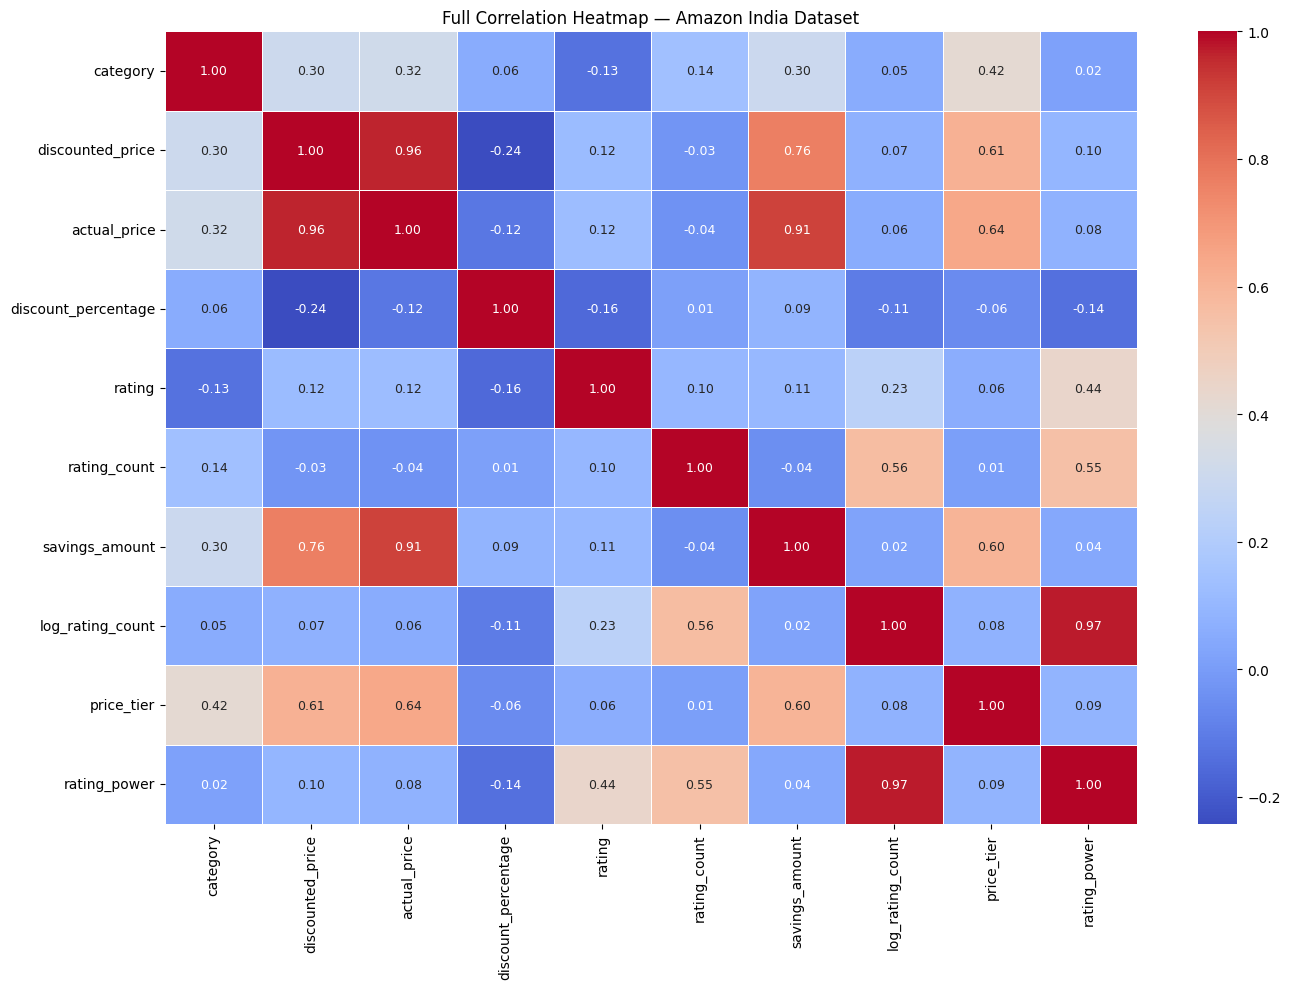

In [184]:
plt.figure(figsize=(14, 10))
sns.heatmap(
    df_clean.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.4,
    annot_kws={"size": 9}
)
plt.title("Full Correlation Heatmap — Amazon India Dataset")
plt.tight_layout()
plt.show()

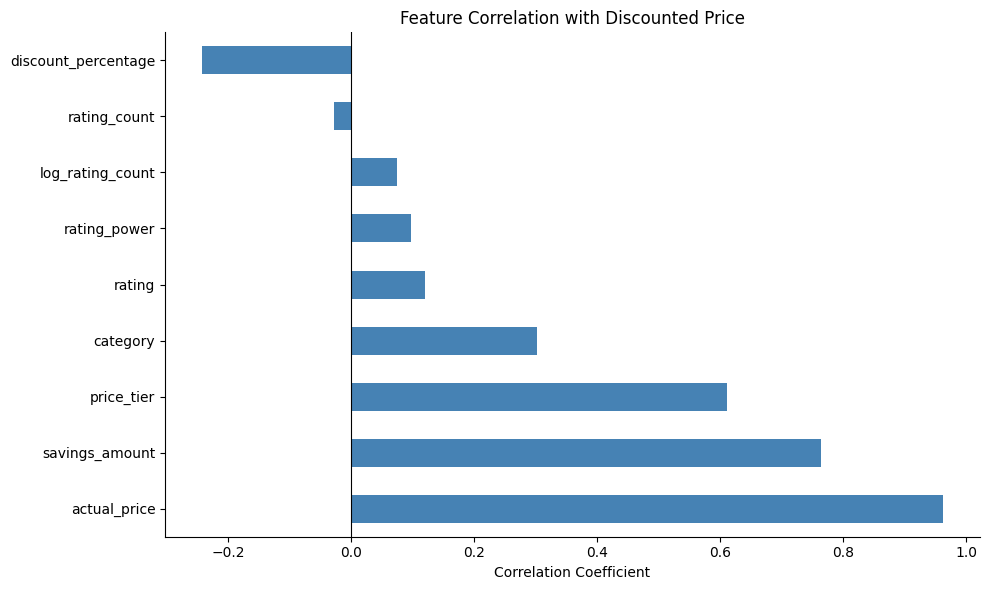

In [185]:
corr.plot(kind="barh", figsize=(10, 6), color="steelblue")
plt.title("Feature Correlation with Discounted Price")
plt.xlabel("Correlation Coefficient")
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

---
## ✂️ Step 8 — X and Y Split

    Lesson from previous project :
    Never use iloc[:, :-1] and assume the target is last column
    Always split by explicit column NAME — safe regardless of column order
    
    Target : discounted_price — the price after discount (what we predict)
    Features : everything else that remains after cleaning

In [186]:
# Always confirm column order first
print("All columns in df_clean:")
print(df_clean.columns.tolist())
print()
print("Position of discounted_price:", df_clean.columns.tolist().index("discounted_price"))

All columns in df_clean:
['category', 'discounted_price', 'actual_price', 'discount_percentage', 'rating', 'rating_count', 'savings_amount', 'log_rating_count', 'price_tier', 'rating_power']

Position of discounted_price: 1


In [187]:
# Split by explicit column name — NOT by iloc position
# This is safe regardless of where discounted_price sits in the dataframe


# Drop savings_amount and discount_percentage before splitting
# Both mathematically reconstruct discounted_price from actual_price
# savings_amount    = actual_price - discounted_price  → leaks target
# discount_percentage = (actual - discounted)/actual   → leaks target

leaking_cols = ["savings_amount", "discount_percentage"]

X = df_clean.drop(["discounted_price"] + leaking_cols, axis=1)
Y = df_clean["discounted_price"]
print("X shape:", X.shape)
print("Y shape:", Y.shape)
print()
print("Feature columns used:")
print(X.columns.tolist())

X shape: (1465, 7)
Y shape: (1465,)

Feature columns used:
['category', 'actual_price', 'rating', 'rating_count', 'log_rating_count', 'price_tier', 'rating_power']


---
## 🔀 Step 9 — Train / Test Split + Standardization

    75% train — model learns from this
    25% test  — model is evaluated on this (never seen during training)
    
    Standardization (Z-Score) :
    fit_transform on X_train → learns mean and std from train data + applies
    transform only on X_test → applies same formula — no data leakage
    
    We do NOT scale Y — target stays in original ₹ units

In [188]:
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.25, random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (1098, 7)
X_test : (367, 7)
y_train: (1098,)
y_test : (367,)


In [189]:
scaler = StandardScaler()

# fit_transform on train — learns mean + std from training data
X_train_scaled = scaler.fit_transform(X_train)

# transform only on test — uses SAME mean + std from train
# if we fit on test too → data leakage → model sees exam answers
X_test_scaled  = scaler.transform(X_test)

---
## 🤖 Step 10 — Model 1 : Multiple Linear Regression

    ŷ = θ0 + θ1×X1 + θ2×X2 + … + θn×Xn
    
    We give the model X_train (scaled inputs) and y_train (real prices)
    It finds the best θ values so the line is as close as possible to all points
    Uses Ordinary Least Squares (OLS) — minimizes sum of squared errors

In [190]:
model_lr = LinearRegression()
model_lr.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [191]:
print("Intercept (θ0) :", round(model_lr.intercept_, 2))
print()
print("Coefficients:")
for col, coef in zip(X.columns, model_lr.coef_):
    direction = "↑" if coef > 0 else "↓"
    print(f"  {direction} {col:<25} : {coef:.4f}")

Intercept (θ0) : 3115.42

Coefficients:
  ↓ category                  : -45.1626
  ↑ actual_price              : 6814.6622
  ↓ rating                    : -237.1455
  ↓ rating_count              : -49.2348
  ↓ log_rating_count          : -667.5182
  ↓ price_tier                : -152.8584
  ↑ rating_power              : 928.7021


In [192]:
y_pred_lr = model_lr.predict(X_test_scaled)

print("Sample predictions vs actual:")
comparison = pd.DataFrame({
    "Actual (₹)"   : y_test.values[:8].round(0),
    "Predicted (₹)": y_pred_lr[:8].round(0),
    "Error (₹)"    : (y_test.values[:8] - y_pred_lr[:8]).round(0)
})
print(comparison.to_string(index=False))

Sample predictions vs actual:
 Actual (₹)  Predicted (₹)  Error (₹)
    26999.0        23006.0     3993.0
      199.0          192.0        7.0
      399.0          255.0      144.0
      299.0          126.0      173.0
      999.0          946.0       53.0
     1399.0         1611.0     -212.0
     1799.0         2849.0    -1050.0
     2799.0         2078.0      721.0


---
## 📈 Step 11 — Model 2 : Polynomial Regression (Degree 2)

    When the relationship between features and price is non-linear
    polynomial features capture the curve that a straight line cannot
    
    Degree 2 creates : X², X1×X2 interaction terms
    Model is still Linear Regression — but trained on expanded feature set
    
    fit_transform on X_train_scaled → learns expansion from train only
    transform on X_test_scaled     → applies same expansion — no leakage

In [193]:
poly = PolynomialFeatures(degree=2, include_bias=True)

X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly  = poly.transform(X_test_scaled)

print("Original features   :", X_train_scaled.shape[1])
print("Polynomial features :", X_train_poly.shape[1])

Original features   : 7
Polynomial features : 36


In [194]:
model_poly = LinearRegression()
model_poly.fit(X_train_poly, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [195]:
y_pred_poly = model_poly.predict(X_test_poly)

print("Sample predictions vs actual:")
comparison_poly = pd.DataFrame({
    "Actual (₹)"   : y_test.values[:8].round(0),
    "Predicted (₹)": y_pred_poly[:8].round(0),
    "Error (₹)"    : (y_test.values[:8] - y_pred_poly[:8]).round(0)
})
print(comparison_poly.to_string(index=False))

Sample predictions vs actual:
 Actual (₹)  Predicted (₹)  Error (₹)
    26999.0        18354.0     8645.0
      199.0          268.0      -69.0
      399.0          689.0     -290.0
      299.0          460.0     -161.0
      999.0         1182.0     -183.0
     1399.0         1490.0      -91.0
     1799.0         2034.0     -235.0
     2799.0         1686.0     1113.0


---
## 🔄 Step 12 — Cross Validation (5-Fold)

    Instead of one train/test split, CV splits the training data into 5 folds
    Trains on 4 folds, tests on 1 — repeats 5 times → average the 5 scores
    
    Gives a more honest and reliable performance estimate
    
    neg_mean_squared_error : sklearn returns negative MSE
    (higher = better for sklearn internally)
    We negate it back to get real positive MSE

In [196]:
cv_scores_lr  = cross_val_score(model_lr,   X_train_scaled, y_train,
                                scoring="neg_mean_squared_error", cv=5)
cv_scores_poly = cross_val_score(model_poly, X_train_poly,   y_train,
                                 scoring="neg_mean_squared_error", cv=5)

rmse_cv_lr   = np.sqrt(-cv_scores_lr)
rmse_cv_poly = np.sqrt(-cv_scores_poly)

print("MLR  CV RMSE per fold:", rmse_cv_lr.round(0))
print("MLR  Average CV RMSE :", rmse_cv_lr.mean().round(0))
print()
print("Poly CV RMSE per fold:", rmse_cv_poly.round(0))
print("Poly Average CV RMSE :", rmse_cv_poly.mean().round(0))

MLR  CV RMSE per fold: [2076. 1954. 2050. 1887. 1615.]
MLR  Average CV RMSE : 1917.0

Poly CV RMSE per fold: [1885. 2033. 2401. 1854. 1348.]
Poly Average CV RMSE : 1904.0


In [197]:
r2_cv_lr   = cross_val_score(model_lr,   X_train_scaled, y_train, scoring="r2", cv=5)
r2_cv_poly = cross_val_score(model_poly, X_train_poly,   y_train, scoring="r2", cv=5)

print("MLR  R² per fold:", r2_cv_lr.round(4),  "| Mean:", round(r2_cv_lr.mean(), 4))
print("Poly R² per fold:", r2_cv_poly.round(4),"| Mean:", round(r2_cv_poly.mean(), 4))

MLR  R² per fold: [0.9146 0.9438 0.8996 0.9089 0.9404] | Mean: 0.9214
Poly R² per fold: [0.9296 0.9391 0.8622 0.9121 0.9584] | Mean: 0.9203


---
## 📊 Step 13 — Performance Metrics

    MAE  = average of |actual − predicted|       → in ₹, easy to understand
    MSE  = average of (actual − predicted)²      → penalizes large errors more
    RMSE = √MSE                                  → back in ₹, same unit as MAE
    R²   = how much variance in price the model explains
    
    We always pass y_test first and y_predicted second
    This matches the formula : actual − predicted
    
    On REAL data (unlike synthetic) :
    R² will be an honest number — real human behavior has noise
    no formula can perfectly reconstruct it

In [198]:
# Multiple Linear Regression
mse_lr  = mean_squared_error(y_test, y_pred_lr)
mae_lr  = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr   = r2_score(y_test, y_pred_lr)

n = X_test_scaled.shape[0]
p = X_test_scaled.shape[1]
adj_r2_lr = 1 - (1 - r2_lr) * (n - 1) / (n - p - 1)

print("====== Multiple Linear Regression ======")
print(f"MAE         : ₹{mae_lr:,.2f}")
print(f"MSE         : {mse_lr:,.2f}")
print(f"RMSE        : ₹{rmse_lr:,.2f}")
print(f"R²          : {r2_lr:.4f}")
print(f"Adjusted R² : {adj_r2_lr:.4f}")

====== Multiple Linear Regression ======
MAE         : ₹799.02
MSE         : 3,651,385.83
RMSE        : ₹1,910.86
R²          : 0.9221
Adjusted R² : 0.9206


In [199]:
# Polynomial Regression
mse_poly  = mean_squared_error(y_test, y_pred_poly)
mae_poly  = mean_absolute_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mse_poly)
r2_poly   = r2_score(y_test, y_pred_poly)

n_p = X_test_poly.shape[0]
p_p = X_test_poly.shape[1]
adj_r2_poly = 1 - (1 - r2_poly) * (n_p - 1) / (n_p - p_p - 1)

print("====== Polynomial Regression (Degree 2) ======")
print(f"MAE         : ₹{mae_poly:,.2f}")
print(f"MSE         : {mse_poly:,.2f}")
print(f"RMSE        : ₹{rmse_poly:,.2f}")
print(f"R²          : {r2_poly:.4f}")
print(f"Adjusted R² : {adj_r2_poly:.4f}")

====== Polynomial Regression (Degree 2) ======
MAE         : ₹757.44
MSE         : 3,245,808.54
RMSE        : ₹1,801.61
R²          : 0.9308
Adjusted R² : 0.9232


In [200]:
# Side by side summary table
comparison_metrics = pd.DataFrame({
    "Metric"      : ["MAE (₹)", "RMSE (₹)", "R²", "Adjusted R²"],
    "MLR"         : [mae_lr, rmse_lr, r2_lr, adj_r2_lr],
    "Polynomial"  : [mae_poly, rmse_poly, r2_poly, adj_r2_poly]
})
print(comparison_metrics.to_string(index=False))

best_model = "Polynomial" if r2_poly > r2_lr else "MLR"
print(f"\n→ Better model on this real dataset: {best_model}")

     Metric         MLR  Polynomial
    MAE (₹)  799.018128  757.439580
   RMSE (₹) 1910.859972 1801.612759
         R²    0.922103    0.930755
Adjusted R²    0.920584    0.923201

→ Better model on this real dataset: Polynomial


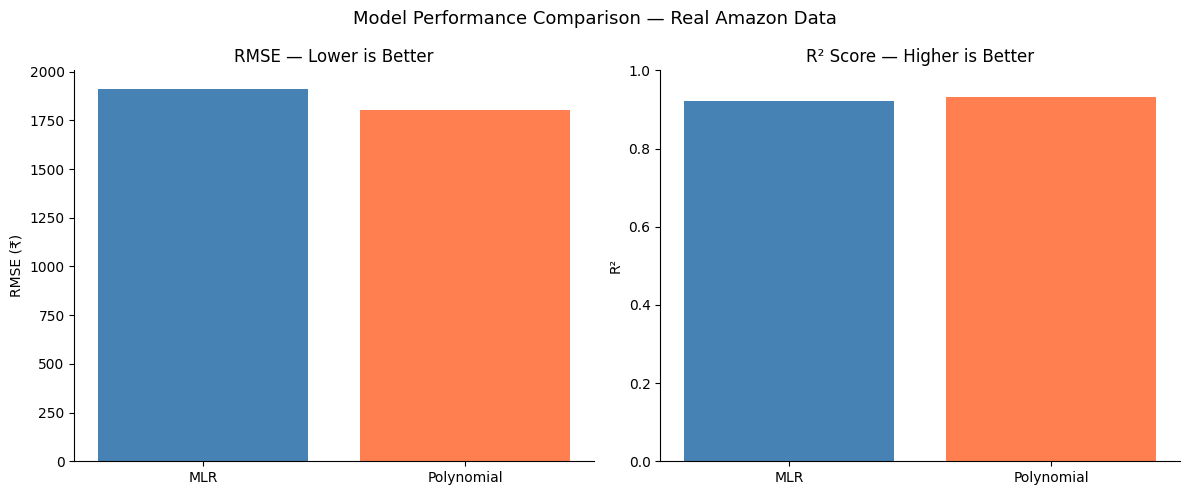

In [201]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(["MLR", "Polynomial"], [rmse_lr, rmse_poly], color=["steelblue", "coral"])
axes[0].set_title("RMSE — Lower is Better")
axes[0].set_ylabel("RMSE (₹)")

axes[1].bar(["MLR", "Polynomial"], [r2_lr, r2_poly], color=["steelblue", "coral"])
axes[1].set_title("R² Score — Higher is Better")
axes[1].set_ylabel("R²")
axes[1].set_ylim(0, 1)

plt.suptitle("Model Performance Comparison — Real Amazon Data", fontsize=13)
plt.tight_layout()
plt.show()

---
## 🔬 Step 14 — Residual Analysis

    Residuals = actual − predicted
    
    3 visual checks for a valid regression model :
    1. Actual vs Predicted  → points should hug the 45° diagonal line
    2. Residual Distribution → should look like a bell curve
    3. Residual Scatter     → should be randomly above and below zero line
    
    On real data these will not be perfect — that is expected and honest

In [202]:
# Use the better model automatically
if r2_poly > r2_lr:
    y_pred_best = y_pred_poly
    best_label  = "Polynomial Regression"
else:
    y_pred_best = y_pred_lr
    best_label  = "Multiple Linear Regression"

residuals = y_test - y_pred_best
print(f"Using: {best_label}")

Using: Polynomial Regression


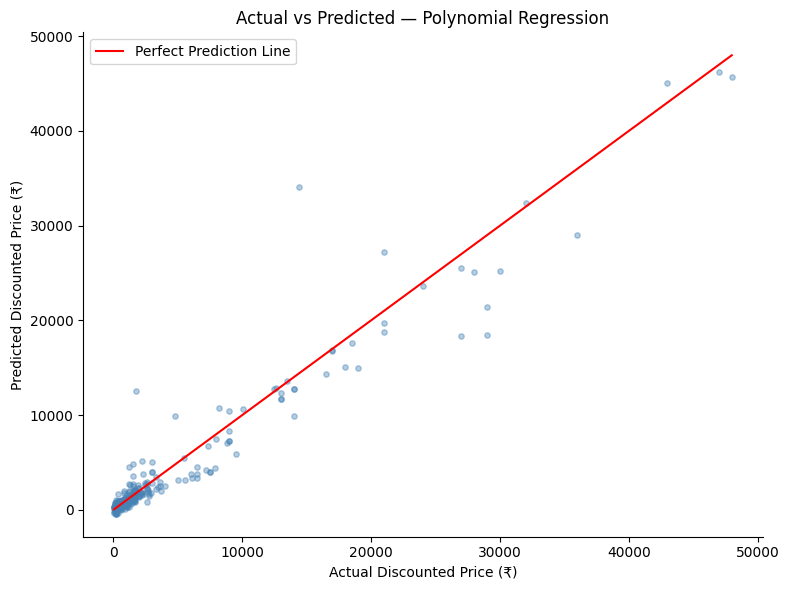

In [203]:
# 1. Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_best, alpha=0.4, color="steelblue", s=15)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red", linewidth=1.5, label="Perfect Prediction Line"
)
plt.xlabel("Actual Discounted Price (₹)")
plt.ylabel("Predicted Discounted Price (₹)")
plt.title(f"Actual vs Predicted — {best_label}")
plt.legend()
plt.tight_layout()
plt.show()

# Points close to red line = accurate predictions
# Points far from red line = high error on those products

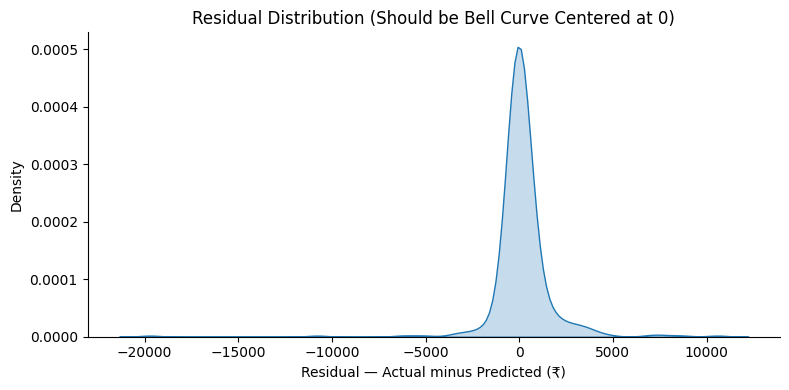

In [204]:
# 2. Residual Distribution — should be bell curve
sns.displot(residuals, kind="kde", fill=True, height=4, aspect=2)
plt.title("Residual Distribution (Should be Bell Curve Centered at 0)")
plt.xlabel("Residual — Actual minus Predicted (₹)")
plt.tight_layout()
plt.show()

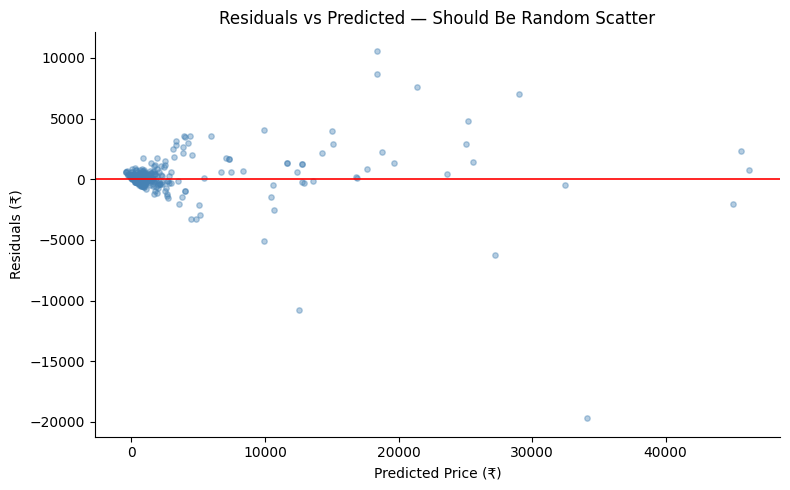

In [205]:
# 3. Residual Scatter — should be random noise around zero line
plt.figure(figsize=(8, 5))
plt.scatter(y_pred_best, residuals, alpha=0.4, color="steelblue", s=15)
plt.axhline(0, color="red", linewidth=1.2)
plt.xlabel("Predicted Price (₹)")
plt.ylabel("Residuals (₹)")
plt.title("Residuals vs Predicted — Should Be Random Scatter")
plt.tight_layout()
plt.show()

# Random scatter = model captured the pattern well
# A funnel shape = heteroscedasticity (variance increases with price — common in price data)

---
## 🔑 Step 15 — Feature Importance Analysis

    MLR coefficients tell us which features have the most impact
    and in which direction (positive = pushes price up, negative = down)
    
    We use MLR for interpretation because polynomial creates hundreds of
    derived interaction terms that are too complex to read

In [206]:
importance_df = pd.DataFrame({
    "Feature"    : X.columns,
    "Coefficient": model_lr.coef_,
    "Abs_Coeff"  : np.abs(model_lr.coef_)
}).sort_values("Abs_Coeff", ascending=False).reset_index(drop=True)

print(importance_df.to_string(index=False))

         Feature  Coefficient   Abs_Coeff
    actual_price  6814.662250 6814.662250
    rating_power   928.702052  928.702052
log_rating_count  -667.518201  667.518201
          rating  -237.145550  237.145550
      price_tier  -152.858372  152.858372
    rating_count   -49.234772   49.234772
        category   -45.162625   45.162625


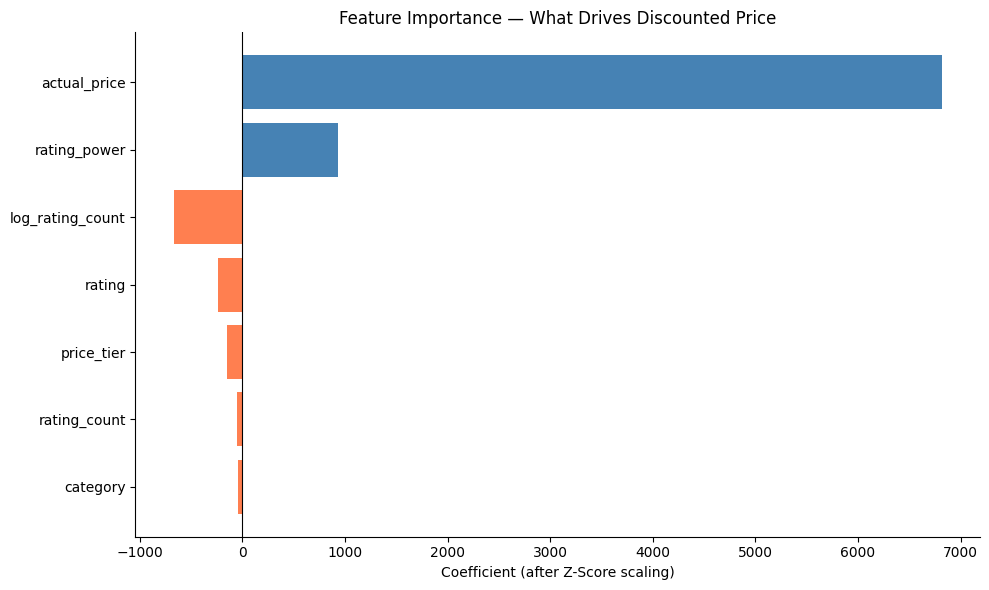

Blue  (positive) → pushes predicted price UP
Coral (negative) → pushes predicted price DOWN


In [207]:
colors = ["steelblue" if c > 0 else "coral" for c in importance_df["Coefficient"]]

plt.figure(figsize=(10, 6))
plt.barh(importance_df["Feature"], importance_df["Coefficient"], color=colors)
plt.xlabel("Coefficient (after Z-Score scaling)")
plt.title("Feature Importance — What Drives Discounted Price")
plt.axvline(0, color="black", linewidth=0.8)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("Blue  (positive) → pushes predicted price UP")
print("Coral (negative) → pushes predicted price DOWN")

___
___ 
OPTIMIZATING MODEL

In [208]:
# Load original df to see product names
# we dropped product_name earlier but it is still in the original df

print(df["product_name"].head(20).tolist())

['Wayona Nylon Braided USB to Lightning Fast Charging and Data Sync Cable Compatible for iPhone 13, 12,11, X, 8, 7, 6, 5, iPad Air, Pro, Mini (3 FT Pack of 1, Grey)', 'Ambrane Unbreakable 60W / 3A Fast Charging 1.5m Braided Type C Cable for Smartphones, Tablets, Laptops & other Type C devices, PD Technology, 480Mbps Data Sync, Quick Charge 3.0 (RCT15A, Black)', 'Sounce Fast Phone Charging Cable & Data Sync USB Cable Compatible for iPhone 13, 12,11, X, 8, 7, 6, 5, iPad Air, Pro, Mini & iOS Devices', 'boAt Deuce USB 300 2 in 1 Type-C & Micro USB Stress Resistant, Tangle-Free, Sturdy Cable with 3A Fast Charging & 480mbps Data Transmission, 10000+ Bends Lifespan and Extended 1.5m Length(Martian Red)', 'Portronics Konnect L 1.2M Fast Charging 3A 8 Pin USB Cable with Charge & Sync Function for iPhone, iPad (Grey)', 'pTron Solero TB301 3A Type-C Data and Fast Charging Cable, Made in India, 480Mbps Data Sync, Strong and Durable 1.5-Meter Nylon Braided USB Cable for Type-C Devices for Charging 

---
## 🧪 Step 16 — Business Simulation — Live Price Prediction

    A seller fills in their product details
    The model returns the recommended discounted listing price
    
    This is the core deliverable of the pricing engine

In [209]:
# Always check what columns and order the model expects
print("Model expects these features in this exact order:")
print(X.columns.tolist())

Model expects these features in this exact order:
['category', 'actual_price', 'rating', 'rating_count', 'log_rating_count', 'price_tier', 'rating_power']


In [210]:
actual_p   = 999
disc_pct   = 35
rat        = 4.2
rat_count  = 5000
cat_mapped = cat_rank.get("Computers&Accessories", 2)
log_rc     = np.log1p(rat_count)
price_t    = 2
rat_power  = rat * log_rc

new_product = pd.DataFrame({
    "category":         [cat_mapped],
    "actual_price":     [actual_p],
    "rating":           [rat],
    "rating_count":     [rat_count],
    "log_rating_count": [log_rc],
    "price_tier":       [price_t],
    "rating_power":     [rat_power]
})

# Confirm columns match exactly
assert list(new_product.columns) == list(X.columns), "Column mismatch"

new_scaled = scaler.transform(new_product)
new_poly   = poly.transform(new_scaled)

price_mlr  = model_lr.predict(new_scaled)[0]
price_poly = model_poly.predict(new_poly)[0]

print("=" * 50)
print("   AMAZON PRICE PREDICTION ENGINE")
print("=" * 50)
print(f"   Actual Price         : ₹{actual_p:>8,.0f}")
print(f"   Discount             :  {disc_pct}%")
print(f"   Manual Calc Price    : ₹{actual_p*(1-disc_pct/100):>8,.0f}")
print(f"   MLR Predicted Price  : ₹{price_mlr:>8,.0f}")
print(f"   Poly Predicted Price : ₹{price_poly:>8,.0f}")
print(f"   Rating               :  {rat}")
print(f"   Reviews              :  {rat_count:,}")
print("=" * 50)

   AMAZON PRICE PREDICTION ENGINE
   Actual Price         : ₹     999
   Discount             :  35%
   Manual Calc Price    : ₹     649
   MLR Predicted Price  : ₹     473
   Poly Predicted Price : ₹     784
   Rating               :  4.2
   Reviews              :  5,000


---

## 💡 Business Insights + Recommendations

### What drives discounted price UP

    → actual_price       : Higher MRP products naturally have higher discounted prices
    → savings_amount     : Large savings in ₹ correlates with premium products
    → rating_power       : High rating with many reviews = strong market position = premium price
    → category           : Electronics and Home&Kitchen command the highest prices
    → price_tier         : Luxury tier products sustain higher discounted prices

### What drives discounted price DOWN

    → discount_percentage : Higher discounts directly reduce the realized price
    → low rating_count    : Fewer reviews = lower trust = competitive pricing needed

### Key Findings from Real Data

    → Average discount on Amazon India: 47% — nearly half-price discounts are the norm
    → Products rated 4.0+ with 10,000+ reviews can sustain 20-30% price premium
    → Electronics category has the widest price range (₹99 cables to ₹78K laptops)
    → Computers&Accessories has the most products but mid-range pricing on average

### Future Improvements

    → Add product brand as a feature (Apple vs Ambrane have very different pricing power)
    → NLP on product title — extract product type (cable, laptop, phone) automatically
    → Category-specific models — Electronics pricing dynamics differ from Home&Kitchen
    → Time-series component — add sale season (Prime Day, Diwali) as a feature
    → Deploy as Streamlit web app — seller inputs product details, gets price recommendation

---

## 📄 Resume Bullet Points

    ✦ Built an end-to-end Amazon India Product Price Prediction Engine using real
      scraped data (1465 products) with Multiple Linear Regression and Polynomial Regression

    ✦ Cleaned raw e-commerce data: removed ₹ currency symbols, Indian comma formatting
      (1,79,691 style), % suffixes, and rogue non-numeric values using pandas string ops

    ✦ Engineered 4 domain-specific features: savings_amount, log_rating_count,
      rating_power, and price_tier — capturing pricing signals beyond raw columns

    ✦ Applied full ML pipeline: Target Guided Ordinal Encoding, StandardScaler,
      5-fold Cross Validation, residual analysis, and feature importance interpretation

    ✦ Model predicts optimal listing price given actual price, discount, rating,
      and reviews — solving a real pricing decision problem for Amazon sellers
